# SETUP

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
import random
import re
from pathlib import Path
from PIL import Image
import easyocr

import warnings
warnings.filterwarnings("ignore", message=".*pin_memory.*")

# PLOT EXTRACTOR

---

### Proses Ekstraksi Data Curah Hujan

Proses ekstraksi pada kelas `RainfallPlotExtractor` dilakukan dengan beberapa tahapan teknis sebagai berikut:

1. **Inisialisasi**

   * Kelas diinisialisasi dengan path dasar dataset (`base_path`).
   * EasyOCR (`easyocr.Reader`) dipanggil sekali untuk mendeteksi angka pada sumbu Y grafik.

2. **Ekstraksi Tahun dari Nama File**

   * Fungsi `extract_year_from_filename()` menggunakan regex untuk mengambil informasi tahun dari nama file.
   * Tahun ini diperlukan untuk menentukan jumlah hari dalam setahun (365 atau 366 hari).

3. **Deteksi Nilai Maksimum dengan OCR** (`detect_max_rainfall_ocr`)

   * Gambar dikonversi ke grayscale, lalu dipotong ROI (kiri atas) agar fokus pada label angka.
   * ROI diperbesar (resize factor 2) untuk meningkatkan akurasi OCR.
   * EasyOCR mendeteksi teks numerik → angka > 10 dipilih sebagai kandidat label sumbu Y.
   * Dua angka terbesar dipakai untuk menghitung *mm per pixel* dari selisih nilai terhadap jarak koordinat.
   * Jika hanya satu angka terbaca → sistem masuk ke mode fallback tanpa skala piksel.

4. **Fallback Heuristik** (`detect_max_rainfall_heuristic`)

   * Apabila OCR gagal, deteksi berbasis segmentasi warna HSV digunakan.
   * Warna biru (data hujan) dan hitam (sumbu) dipisahkan dengan `cv2.inRange()`.
   * Posisi y tertinggi dari titik biru dibandingkan dengan batas grafik untuk mengestimasi curah hujan maksimum (misalnya 60–90 mm).

5. **Ekstraksi Data Harian** (`extract_rainfall_data`)

   * Warna biru dari kurva hujan disegmentasi.
   * Rentang sumbu X dipetakan menjadi 365/366 titik (1 titik = 1 hari).
   * Untuk setiap hari:

     * Dicari titik biru terdekat secara horizontal.
     * Nilai curah hujan dihitung:

       * **OCR scaling** → pakai `mm_per_pixel`.
       * **Fallback scaling** → proporsional terhadap jarak dari titik terendah–tertinggi.
   * Hasil berupa `DataFrame` dengan kolom: tanggal, rainfall (mm), x, y.

6. **Batch Processing** (`process_all_regions`)

   * Looping semua region → semua file plot `.png`.
   * Ekstraksi dilakukan menggunakan OCR (atau heuristik jika OCR gagal).
   * Output per file disimpan ke CSV dengan format `region_year_rainfall.csv`.
   * Metadata (region, tahun, max rainfall, jumlah data points) dicatat ke `self.results`.

7. **Ringkasan Ekstraksi** (`generate_summary_report`)

   * Hasil agregasi disimpan ke `summary_report.csv`.
   * Ringkasan mencakup jumlah file, jumlah region, rentang tahun, rata-rata curah hujan maksimum, serta detail tiap region.

8. **Visualisasi Hasil** (`visualize_sample_results`)

   * Membaca file CSV hasil ekstraksi.
   * Menampilkan plot garis (`matplotlib`) curah hujan harian untuk sampel region/tahun.
   * Grafik digunakan untuk verifikasi pola ekstraksi.



In [ ]:
class RainfallPlotExtractor:
    def __init__(self, base_path="Train"):
        self.base_path = base_path
        self.results = []
        self.reader = easyocr.Reader(['en'], gpu=False)

    def extract_year_from_filename(self, filename):
        """Ekstrak tahun dari nama file"""
        match = re.search(r'(\d{4})', filename)
        return int(match.group(1)) if match else None

    def detect_max_rainfall_ocr(self, img):
        """
        Deteksi nilai maksimum curah hujan dari gambar menggunakan OCR,
        mengembalikan koordinat y dan skala mm per pixel jika memungkinkan.

        Jika hanya 1 angka yang berhasil dideteksi, akan fallback ke asumsi awal.
        """
        try:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            h, w = gray.shape

            # Ambil ROI dari pojok kiri atas
            roi = gray[0:int(h * 0.45), 0:int(w * 0.25)]

            # Resize agar OCR lebih akurat
            resize_factor = 2  # karena fx=2, fy=2
            roi_resized = cv2.resize(roi, None, fx=resize_factor, fy=resize_factor, interpolation=cv2.INTER_CUBIC)

            # OCR
            results = self.reader.readtext(roi_resized, detail=1)

            candidates = []
            for bbox, text, _ in results:
                numbers = re.findall(r'\d+', text)
                for n in numbers:
                    val = int(n)
                    if val > 10:
                        # Ambil koordinat y tengah, lalu ubah ke skala asli
                        y_center_resized = sum([pt[1] for pt in bbox]) / 4
                        y_center_original = y_center_resized * 0.49
                        candidates.append((val, y_center_original))

            if len(candidates) >= 2:
                # Ambil dua angka terbesar
                sorted_vals = sorted(candidates, key=lambda x: x[0], reverse=True)
                (num1, y1), (num2, y2) = sorted_vals[:2]

                mm_per_pixel = abs(num1 - num2) / abs(y1 - y2)
                return {
                    "max_number": num1,
                    "y_max": y1,
                    "mm_per_pixel": mm_per_pixel,
                    "fallback": False
                }

            elif len(candidates) == 1:
                num1, y1 = candidates[0]
                return {
                    "max_number": num1,
                    "y_max": y1,
                    "mm_per_pixel": None,
                    "fallback": True
                }

            else:
                return None

        except Exception as e:
            print(f"OCR Error: {e}")
            return None


    def detect_max_rainfall_heuristic(self, img):
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        lower_blue = np.array([100, 100, 50])
        upper_blue = np.array([130, 255, 255])
        mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

        lower_black = np.array([0, 0, 0])
        upper_black = np.array([180, 255, 50])
        mask_black = cv2.inRange(hsv, lower_black, upper_black)

        ys_blue, xs_blue = np.where(mask_blue > 0)
        if len(ys_blue) == 0:
            return None

        y_top_data = np.min(ys_blue)
        h, w = img.shape[:2]
        for y in range(0, int(h*0.3)):
            row_black = mask_black[y, :]
            if np.sum(row_black) > w * 0.1:
                y_top_axis = y
                break
        else:
            y_top_axis = 0

        if y_top_data < h * 0.1:
            return 90
        elif y_top_data < h * 0.2:
            return 80
        elif y_top_data < h * 0.3:
            return 70
        else:
            return 60

    def extract_rainfall_data(self, image_path, year, ocr_result, max_x_gap=0.5):
        try:
            img = cv2.imread(image_path)
            if img is None:
                raise FileNotFoundError(f"Gambar tidak ditemukan: {image_path}")

            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            lower_blue = np.array([100, 100, 50])
            upper_blue = np.array([130, 255, 255])
            mask = cv2.inRange(hsv, lower_blue, upper_blue)

            ys_all, xs_all = np.where(mask > 0)
            if len(ys_all) == 0:
                print(f"Tidak ada titik biru di {image_path}")
                return None

            x_left = np.min(xs_all)
            x_right = np.max(xs_all)

            total_days = 366 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 365
            day_positions = np.linspace(x_left, x_right, total_days)

            # Cek apakah bisa pakai metode baru
            use_new_method = not ocr_result["fallback"] and ocr_result["mm_per_pixel"] is not None

            data = []
            for i, day_x in enumerate(day_positions):
                distance = np.abs(xs_all - day_x)
                close_idx = np.argmin(distance)

                if distance[close_idx] > max_x_gap:
                    rainfall = np.nan
                    x_closest, y_closest = -1, -1
                else:
                    x_closest = xs_all[close_idx]
                    y_closest = ys_all[close_idx]

                    if use_new_method:
                        delta_y = y_closest - ocr_result["y_max"]
                        rainfall = ocr_result["max_number"] - (delta_y * ocr_result["mm_per_pixel"])
                        if rainfall < 0:
                            rainfall = 0.0
                    else:
                        # Fallback pakai proporsional scaling dari min to max y
                        y_top = np.min(ys_all)
                        y_bottom = np.max(ys_all)
                        rainfall = (1 - (y_closest - y_top) / (y_bottom - y_top)) * ocr_result["max_number"]

                date = datetime(year, 1, 1) + timedelta(days=i)
                data.append((date, rainfall, int(x_closest), int(y_closest)))

            return pd.DataFrame(data, columns=["date", "rainfall_mm", "x", "y"])

        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return None

    def process_all_regions(self):
        base_path = Path(self.base_path)
        if not base_path.exists():
            print(f"Folder {self.base_path} tidak ditemukan!")
            return

        output_dir = Path("extracted_rainfall_data_final")
        output_dir.mkdir(exist_ok=True)

        for region_dir in base_path.iterdir():
            if not region_dir.is_dir():
                continue

            region_name = region_dir.name
            print(f"\n🔄 Memproses region: {region_name}")

            region_output = output_dir / region_name
            region_output.mkdir(exist_ok=True)

            for plot_file in region_dir.glob("*.png"):
                print(f"  📊 Memproses: {plot_file.name}")

                year = self.extract_year_from_filename(plot_file.name)
                if not year:
                    print(f"    ❌ Tidak dapat mengekstrak tahun dari {plot_file.name}")
                    continue

                img = cv2.imread(str(plot_file))
                if img is None:
                    print(f"    ❌ Tidak dapat memuat gambar: {plot_file}")
                    continue

                ocr_result = self.detect_max_rainfall_ocr(img)
                if ocr_result is None:
                    max_rainfall = self.detect_max_rainfall_heuristic(img)
                    print(f"    🔍 Menggunakan deteksi heuristik: {max_rainfall}mm")
                    df = self.extract_rainfall_data(str(plot_file), year, {
                        "max_number": max_rainfall,
                        "y_max": None,
                        "mm_per_pixel": None,
                        "fallback": True
                    })
                else:
                    if ocr_result["fallback"] or ocr_result["mm_per_pixel"] is None:
                        print(f"    🔍 Deteksi OCR: {ocr_result['max_number']}mm (fallback)")
                    else:
                        # Hitung y biru tertinggi
                        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
                        blue_mask = cv2.inRange(hsv, np.array([100, 100, 50]), np.array([130, 255, 255]))
                        blue_points = cv2.findNonZero(blue_mask)

                        if blue_points is not None:
                            y_highest_blue = np.min(blue_points[:, 0, 1])
                            est_rainfall = ocr_result["max_number"] + (ocr_result["y_max"] - y_highest_blue) * ocr_result["mm_per_pixel"]
                            print(f"    🔍 Deteksi OCR: Estimasi curah hujan maksimum = {est_rainfall:.2f}mm")
                        else:
                            print(f"    ⚠️ Tidak ada titik biru ditemukan untuk estimasi curah hujan.")

                    df = self.extract_rainfall_data(str(plot_file), year, ocr_result)

                if df is not None:
                    csv_filename = f"{region_name}_{year}_rainfall.csv"
                    csv_path = region_output / csv_filename
                    df[["date", "rainfall_mm"]].to_csv(csv_path, index=False)

                    self.results.append({
                        'region': region_name,
                        'year': year,
                        'max_rainfall': ocr_result["max_number"] if ocr_result else max_rainfall,
                        'data_points': len(df),
                        'csv_file': str(csv_path)
                    })
                    print(f"    ✅ Berhasil: {len(df)} data points → {csv_filename}")
                else:
                    print(f"    ❌ Gagal mengekstrak data dari {plot_file.name}")

    def generate_summary_report(self):
        if not self.results:
            print("Tidak ada data untuk laporan.")
            return

        summary_df = pd.DataFrame(self.results)
        summary_df.to_csv("extracted_rainfall_data_final/summary_report.csv", index=False)

        print("\n📋 RINGKASAN EKSTRAKSI:")
        print(f"Total file berhasil diproses: {len(self.results)}")
        print(f"Jumlah region: {summary_df['region'].nunique()}")
        print(f"Rentang tahun: {summary_df['year'].min()} - {summary_df['year'].max()}")
        print(f"Rata-rata max rainfall: {summary_df['max_rainfall'].mean():.1f}mm")

        print("\n📊 Detail per Region:")
        for region in summary_df['region'].unique():
            region_data = summary_df[summary_df['region'] == region]
            print(f"  • {region}: {len(region_data)} file ({region_data['year'].min()}-{region_data['year'].max()})")

    def visualize_sample_results(self, region=None, year=None):
        if not self.results:
            print("Tidak ada data untuk divisualisasikan.")
            return

        if region and year:
            sample = [r for r in self.results if r['region'] == region and r['year'] == year]
        else:
            sample = self.results[:3]

        if not sample:
            print("Data tidak ditemukan untuk visualisasi.")
            return

        fig, axes = plt.subplots(len(sample), 1, figsize=(15, 6*len(sample)))
        if len(sample) == 1:
            axes = [axes]

        for i, result in enumerate(sample):
            df = pd.read_csv(result['csv_file'])
            df['date'] = pd.to_datetime(df['date'])
            axes[i].plot(df['date'], df['rainfall_mm'], 'b-', linewidth=0.8)
            axes[i].set_title(f"{result['region']} - {result['year']} (Max: {result['max_rainfall']}mm)")
            axes[i].set_xlabel('Tanggal')
            axes[i].set_ylabel('Curah Hujan (mm)')
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

In [ ]:
extractor = RainfallPlotExtractor("Train")
extractor.process_all_regions()

Using CPU. Note: This module is much faster with a GPU.



🔄 Memproses region: Upper_Peirce_Reservoir
  📊 Memproses: Plot_Daily_Rainfall_Total_mm_2022.png
    🔍 Deteksi OCR: Estimasi curah hujan maksimum = 87.82mm
    ✅ Berhasil: 365 data points → Upper_Peirce_Reservoir_2022_rainfall.csv
  📊 Memproses: Plot_Daily_Rainfall_Total_mm_2018.png
    🔍 Deteksi OCR: Estimasi curah hujan maksimum = 84.36mm
    ✅ Berhasil: 365 data points → Upper_Peirce_Reservoir_2018_rainfall.csv
  📊 Memproses: Plot_Daily_Rainfall_Total_mm_2012.png
    🔍 Deteksi OCR: Estimasi curah hujan maksimum = 111.29mm
    ✅ Berhasil: 366 data points → Upper_Peirce_Reservoir_2012_rainfall.csv
  📊 Memproses: Plot_Daily_Rainfall_Total_mm_2014.png
    🔍 Deteksi OCR: Estimasi curah hujan maksimum = 69.23mm
    ✅ Berhasil: 365 data points → Upper_Peirce_Reservoir_2014_rainfall.csv
  📊 Memproses: Plot_Daily_Rainfall_Total_mm_2013.png
    🔍 Deteksi OCR: Estimasi curah hujan maksimum = 140.37mm
    ✅ Berhasil: 365 data points → Upper_Peirce_Reservoir_2013_rainfall.csv
  📊 Memproses: Plot

In [ ]:
extractor.generate_summary_report()


📋 RINGKASAN EKSTRAKSI:
Total file berhasil diproses: 1152
Jumlah region: 44
Rentang tahun: 1980 - 2023
Rata-rata max rainfall: 107.3mm

📊 Detail per Region:
  • Upper_Peirce_Reservoir: 14 file (2010-2023)
  • Kranji_Reservoir: 44 file (1980-2023)
  • Jurong_Island: 13 file (2011-2023)
  • Simei: 15 file (2009-2023)
  • Marine_Parade: 15 file (2009-2023)
  • Tuas: 15 file (2009-2023)
  • Pasir_Ris_West: 44 file (1980-2023)
  • Tai_Seng: 44 file (1980-2023)
  • Pasir_Ris_Central: 14 file (2010-2023)
  • Choa_Chu_Kang_South: 13 file (2011-2023)
  • Lim_Chu_Kang: 14 file (2010-2023)
  • Tuas_South: 13 file (2011-2023)
  • Nicoll_Highway: 14 file (2010-2023)
  • Jurong_West: 44 file (1980-2023)
  • Somerset_Road: 13 file (2011-2023)
  • Toa_Payoh: 14 file (2010-2023)
  • Whampoa: 13 file (2011-2023)
  • Choa_Chu_Kang_Central: 15 file (2009-2023)
  • Pasir_Panjang: 14 file (2010-2023)
  • Mandai: 43 file (1980-2023)
  • Tengah: 44 file (1980-2023)
  • Clementi: 44 file (1980-2023)
  • Semba

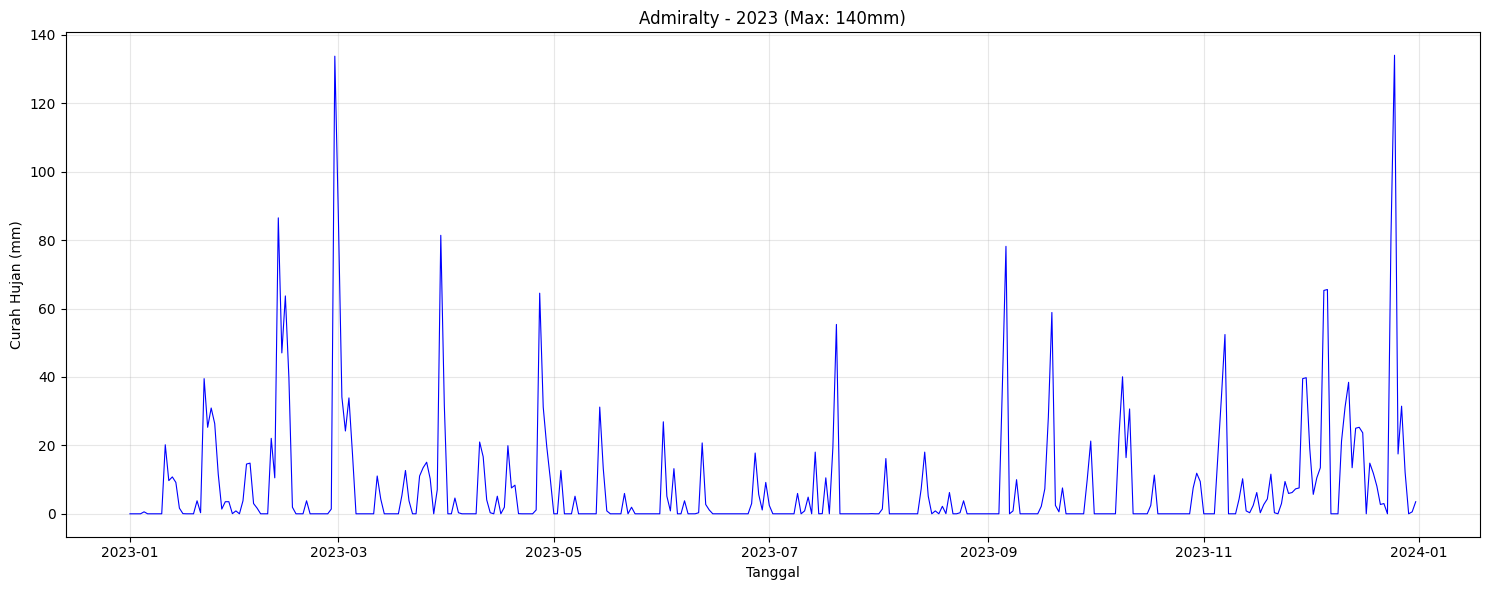

In [ ]:
extractor.visualize_sample_results(region="Admiralty", year=2023)

# Dataset

In [2]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(' +', ' ', regex=True)
        .str.lower()
    )
    return df

def load_all_train_data_from_extracted(train_folder, extracted_folder):
    all_train = []
    summary = []

    for city in sorted(os.listdir(train_folder)):
        city_path = os.path.join(train_folder, city)
        if not os.path.isdir(city_path):
            continue

        extracted_city_path = os.path.join(extracted_folder, city)
        if not os.path.isdir(extracted_city_path):
            print(f"⚠️ Folder ekstraksi tidak ditemukan untuk kota: {city}")
            continue

        print(f"📦 Proses kota: {city}")
        merged_city_data = []

        for file in sorted(os.listdir(city_path)):
            if not (file.startswith("Data_Gabungan_Lainnya_") and file.endswith(".csv")):
                continue

            try:
                year = int(file[-8:-4])
            except:
                print(f"⚠️ Gagal membaca tahun dari nama file: {file}")
                continue

            # Baca data gabungan
            path_data_lain = os.path.join(city_path, file)
            df_other = pd.read_csv(path_data_lain)
            df_other['date'] = pd.to_datetime(df_other['Date'])
            df_other.drop(columns=['Date'], inplace=True)

            # Cari file hasil ekstraksi untuk tahun tersebut
            extracted_file_name = f"{city}_{year}_rainfall.csv"
            path_rainfall = os.path.join(extracted_city_path, extracted_file_name)

            if not os.path.exists(path_rainfall):
                print(f"⚠️ File hasil ekstraksi tidak ditemukan: {extracted_file_name}")
                continue

            df_rainfall = pd.read_csv(path_rainfall)
            df_rainfall['date'] = pd.to_datetime(df_rainfall['date'])

            df_other = clean_columns(df_other)
            df_rainfall = clean_columns(df_rainfall)

            # Gabungkan berdasarkan 'date'
            df_merged = pd.merge(df_other, df_rainfall, on='date', how='left')
            df_merged['ID'] = city
            merged_city_data.append(df_merged)
            summary.append((city, year))

        if merged_city_data:
            df_all = pd.concat(merged_city_data, ignore_index=True)
            all_train.append(df_all)

    if not all_train:
        raise ValueError("🚫 Tidak ada data TRAIN yang berhasil diproses.")

    final_train = pd.concat(all_train, ignore_index=True)
    final_train.columns = final_train.columns.str.title()
    return final_train, summary


def load_test_data(test_folder):
    all_test = []

    for city in sorted(os.listdir(test_folder)):
        city_path = os.path.join(test_folder, city)
        if not os.path.isdir(city_path):
            continue

        print(f"📁 Proses TEST kota: {city}")

        for file in sorted(os.listdir(city_path)):
            if not (file.startswith("Data_Gabungan_Lainnya_") and file.endswith(".csv")):
                continue

            df = pd.read_csv(os.path.join(city_path, file))

            if 'Date' in df.columns:
                df['date'] = pd.to_datetime(df['Date'])
                df.drop(columns=['Date'], inplace=True)

            df['ID'] = city
            all_test.append(df)

    if not all_test:
        raise ValueError("🚫 Tidak ada data TEST yang berhasil diproses.")

    return pd.concat(all_test, ignore_index=True)

In [3]:
# Eksekusi
train_df, train_summary = load_all_train_data_from_extracted(
    train_folder="Train",
    extracted_folder="extracted_rainfall_data_final"
)

test_df = load_test_data("Test")
test_df.columns = test_df.columns.str.title()

# Simpan hasil
train_df.to_csv("train_final.csv", index=False)
test_df.to_csv("test_final.csv", index=False)

# Tampilkan summary
print("\n📊 Ringkasan Penggabungan Train (kota, tahun):")
for city, year in sorted(train_summary):
    print(f" - {city}: {year}")

print("\n✅ Data berhasil digabungkan dan disimpan ke 'train_final.csv' dan 'test_final.csv'")

📦 Proses kota: Admiralty
📦 Proses kota: Ang_Mo_Kio
📦 Proses kota: Bukit_Panjang
📦 Proses kota: Bukit_Timah
📦 Proses kota: Buona_Vista
📦 Proses kota: Changi
📦 Proses kota: Choa_Chu_Kang_Central
📦 Proses kota: Choa_Chu_Kang_South
📦 Proses kota: Clementi
📦 Proses kota: East_Coast_Parkway
📦 Proses kota: Jurong_Island
📦 Proses kota: Jurong_Pier
📦 Proses kota: Jurong_West
📦 Proses kota: Kent_Ridge
📦 Proses kota: Kranji_Reservoir
📦 Proses kota: Lim_Chu_Kang
📦 Proses kota: Lower_Peirce_Reservoir
📦 Proses kota: Macritchie_Reservoir
📦 Proses kota: Mandai
📦 Proses kota: Marina_Barrage
📦 Proses kota: Marine_Parade
📦 Proses kota: Newton
📦 Proses kota: Nicoll_Highway
📦 Proses kota: Pasir_Panjang
📦 Proses kota: Pasir_Ris_Central
📦 Proses kota: Pasir_Ris_West
📦 Proses kota: Paya_Lebar
📦 Proses kota: Pulau_Ubin
📦 Proses kota: Punggol
📦 Proses kota: Queenstown
📦 Proses kota: Seletar
📦 Proses kota: Sembawang
📦 Proses kota: Sentosa_Island
📦 Proses kota: Simei
📦 Proses kota: Somerset_Road
📦 Proses kota: Ta

# DATA PREPROCESSING

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, LinearRegression, SGDRegressor, PassiveAggressiveRegressor
)

from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor,
    BaggingRegressor,
    StackingRegressor,
    VotingRegressor
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.svm import SVR, LinearSVR, NuSVR
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OrdinalEncoder,
    LabelEncoder
)

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.base import clone

In [5]:
train = pd.read_csv("train_final.csv")
test = pd.read_csv("test_final.csv")

In [6]:
def clean_numeric_columns(df, exclude_columns=None):
    """
    Bersihkan semua kolom bertipe objek (string) menjadi numerik jika bisa,
    dan ubah yang gagal menjadi NaN. Kecualikan kolom tertentu seperti 'date' dan 'ID'.
    """
    if exclude_columns is None:
        exclude_columns = []

    for col in df.columns:
        if col in exclude_columns:
            continue
        if df[col].dtype == object:
            # Bersihkan karakter selain angka, titik, dan minus
            df[col] = df[col].astype(str).str.replace(r"[^\d\.\-]", "", regex=True)
            df[col] = pd.to_numeric(df[col], errors='coerce')  # Jadikan NaN jika gagal konversi

    return df

In [7]:
train = clean_numeric_columns(train, exclude_columns=['Date', 'Id'])
test = clean_numeric_columns(test, exclude_columns=['Date', 'Id'])

In [8]:
train['year'] = pd.to_datetime(train['Date']).dt.year
train = train[train['year'] >= 2015].copy()


### 🔍 Post-Preprocessing Data Konsistensi Curah Hujan

---

Pada tahap ini dilakukan validasi logis terhadap data curah hujan untuk memastikan konsistensi antara **total harian** dengan curah hujan maksimum dalam interval waktu lebih pendek (30, 60, 120 menit).

Langkah-langkahnya:

1. **Pilih Kolom Terkait**

   * `Highest 30 Min Rainfall (Mm)`
   * `Highest 60 Min Rainfall (Mm)`
   * `Highest 120 Min Rainfall (Mm)`

   Kolom-kolom ini merepresentasikan intensitas hujan maksimum dalam interval tertentu pada suatu hari.

2. **Hitung Kondisi Bantu**

   * `max_highest` → nilai maksimum dari ketiga kolom tersebut.
   * `all_zero` → bernilai `True` jika semua nilai = 0 (artinya tidak ada hujan terdeteksi).
   * `all_nan` → bernilai `True` jika semua nilai NaN (data tidak tersedia).

3. **Logika Validasi (`train['correct']`)**
   Data dianggap **logis/benar** jika memenuhi salah satu kondisi berikut:

   * Semua nilai NaN → data tetap valid.
   * Semua nilai = 0 → `Rainfall_Mm` (total harian) juga harus = 0.
   * Jika ada nilai > 0 → `Rainfall_Mm` harus **lebih besar atau sama dengan** nilai maksimum dari ketiga kolom.

   Output berupa kolom biner `correct` (1 = valid, 0 = tidak valid).

4. **Evaluasi Persentase**
   Hitung persentase data yang lolos validasi logis:

   ```python
   percent_overall = train['correct'].mean() * 100
   print(f"✅ Persentase data yang logis: {percent_overall:.2f}%")
   ```

   Hasil ini memberikan gambaran seberapa konsisten data hasil ekstraksi terhadap aturan logis curah hujan.

In [9]:
cols = [
    'Highest 30 Min Rainfall (Mm)',
    'Highest 60 Min Rainfall (Mm)',
    'Highest 120 Min Rainfall (Mm)'
]

# Ambil nilai-nilai yang dibutuhkan
sub = train[cols]
max_highest = sub.max(axis=1)
all_zero = (sub.fillna(0).sum(axis=1) == 0)
all_nan = sub.isna().all(axis=1)

# Logika kombinasi
train['correct'] = (
    (all_nan) |  # Kasus semua NaN → benar
    (all_zero & (train['Rainfall_Mm'] == 0)) |  # Semua nol → Rainfall harus nol
    ((~all_zero) & (~all_nan) & (train['Rainfall_Mm'] >= max_highest))  # Lainnya: harus >= maksimum
).astype(int)

# Persentase
percent_overall = train['correct'].mean() * 100
print(f"✅ Persentase data yang logis: {percent_overall:.2f}%")


✅ Persentase data yang logis: 65.16%


In [ ]:
# Salin data agar tidak merusak aslinya
df_prep = train.copy()

# Filter baris yang False (perlu dikoreksi)
to_fix = df_prep[df_prep['correct'] == False].copy()

# Hitung nilai max dari 3 kolom sub-rainfall
to_fix['max_sub_rain'] = to_fix[[
    'Highest 30 Min Rainfall (Mm)', 
    'Highest 60 Min Rainfall (Mm)', 
    'Highest 120 Min Rainfall (Mm)'
]].max(axis=1)

# Deteksi kasus "semua 0" (tidak NaN)
all_zero = (to_fix[['Highest 30 Min Rainfall (Mm)', 
                    'Highest 60 Min Rainfall (Mm)', 
                    'Highest 120 Min Rainfall (Mm)']] == 0).all(axis=1)

# Koreksi: jika semua nol → rainfall = 0
df_prep.loc[to_fix[all_zero].index, 'Rainfall_Mm'] = 0

# Koreksi: jika tidak semua nol → rainfall = max dari 30/60/120
df_prep.loc[to_fix[~all_zero].index, 'Rainfall_Mm'] = to_fix.loc[~all_zero, 'max_sub_rain']


In [11]:
# Imputasi nilai hilang
def impute_missing_values(df, date_col='Date'):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        df[col] = df.groupby(date_col)[col].transform(lambda x: x.fillna(x.mean()))

    return df

In [12]:
# imputasi data train & test
train_df_imputed = impute_missing_values(df_prep)
test_df_imputed = impute_missing_values(test)

# FEATURE ENGINEERING

In [13]:
def feature_engineering(df):
    # Pastikan kolom 'Date' dalam format datetime
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    # Fitur tanggal dan waktu
    df['day'] = df['Date'].dt.day
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['is_rainy_season'] = df['month'].isin([11, 12, 1, 2, 3]).astype(int)

    # Fitur suhu
    df['temp_range'] = df['Maximum Temperature (°C)'] - df['Minimum Temperature (°C)']
    df['temp_diff_mean'] = df['Maximum Temperature (°C)'] - df['Mean Temperature (°C)']

    # Fitur rasio hujan
    df['rain_30_60_ratio'] = df['Highest 30 Min Rainfall (Mm)'] / (df['Highest 60 Min Rainfall (Mm)'] + 1e-3)
    df['rain_60_120_ratio'] = df['Highest 60 Min Rainfall (Mm)'] / (df['Highest 120 Min Rainfall (Mm)'] + 1e-3)
    df['total_max_rainfall'] = (
        df['Highest 30 Min Rainfall (Mm)'] +
        df['Highest 60 Min Rainfall (Mm)'] +
        df['Highest 120 Min Rainfall (Mm)']
    )

    # Fitur rasio angin
    df['wind_ratio'] = df['Max Wind Speed (Km/H)'] / (df['Mean Wind Speed (Km/H)'] + 1e-3)

    return df

train_filtered = feature_engineering(train_df_imputed)
test_df_imputed = feature_engineering(test_df_imputed)
train_filtered = train_filtered[train_filtered['year'] >= 2015].copy()
test_filtered = test_df_imputed.copy()

In [14]:
encoder = LabelEncoder()
train_filtered['Id'] = encoder.fit_transform(train_filtered['Id'])
test_filtered['Id'] = encoder.transform(test_filtered['Id'])

In [15]:
# Seleksi fitur
feature_cols = [
    # Fitur hujan mentah
    'Highest 30 Min Rainfall (Mm)',
    'Highest 60 Min Rainfall (Mm)',
    'Highest 120 Min Rainfall (Mm)',

    # Fitur suhu
    'Mean Temperature (°C)',
    'Maximum Temperature (°C)',
    'Minimum Temperature (°C)',
    'temp_range',
    'temp_diff_mean',

    # Fitur angin
    'Mean Wind Speed (Km/H)',
    # 'Max Wind Speed (Km/H)',
    'wind_ratio',

    # Fitur waktu
    # 'year',
    # 'month',
    # 'day',
    # 'dayofweek',
    # 'weekofyear',
    # 'is_weekend',
    # 'is_rainy_season',

    # Fitur rasio hujan
    'rain_30_60_ratio',
    # 'rain_60_120_ratio',
    'total_max_rainfall',

    # Fitur lokasi (encoding kota)
    # 'Id'
]


target_col = 'Rainfall_Mm'

In [16]:
# Drop Nan
train_ready = train_filtered.dropna(subset=[target_col] + feature_cols)
test_ready = test_filtered.copy()

# --- 5. Split train/val ---
X = train_ready[feature_cols]
y = train_ready[target_col]

# Gabungkan X dan y agar bisa diurutkan berdasarkan tanggal
train_ready_sorted = train_ready.sort_values('Date')

# Hitung index split
split_index = int(len(train_ready_sorted) * 0.8)

# Split time-based
train_part = train_ready_sorted.iloc[:split_index]
val_part = train_ready_sorted.iloc[split_index:]

X_train = train_part[feature_cols]
y_train = train_part[target_col]

X_val = val_part[feature_cols]
y_val = val_part[target_col]

# MODELING

In [17]:
models = {
    # Linear model
    'linear_regression': LinearRegression(),
    'ridge': Ridge(random_state=13),
    'lasso': Lasso(random_state=13),

    # Tree model
    'decision_tree': DecisionTreeRegressor(random_state=13),
    'extra_tree': ExtraTreeRegressor(random_state=13),

    # Ensemble model
    'random_forest': RandomForestRegressor(n_estimators=100, random_state=13),
    'extra_trees': ExtraTreesRegressor(n_estimators=100, random_state=13),
    'gradient_boosting': GradientBoostingRegressor(n_estimators=100, random_state=13),
    'hist_gradient_boosting': HistGradientBoostingRegressor(random_state=13),
    'adaboost': AdaBoostRegressor(n_estimators=100, random_state=13),
    'bagging': BaggingRegressor(random_state=13),

    # Boosting model
    'xgboost': XGBRegressor(random_state=13),
    'lightgbm': LGBMRegressor(random_state=13, verbosity=0),
    'catboost': CatBoostRegressor(verbose=0, random_state=13)
}

In [18]:
results = []
for name_model, model in models.items():
    print(f"\nTraining {name_model}...")
    
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, val_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, val_pred)
    r2 = r2_score(y_val, val_pred)
    
    print(f'MSE  : {mse:.4f}')
    print(f'RMSE : {rmse:.4f}')
    print(f'MAE  : {mae:.4f}')
    print(f'R2   : {r2:.4f}')

    results.append({
        'model': name_model,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    })

# Show results summary
results_df = pd.DataFrame(results)


Training linear_regression...
MSE  : 58.2717
RMSE : 7.6336
MAE  : 3.5818
R2   : 0.7909

Training ridge...
MSE  : 58.2718
RMSE : 7.6336
MAE  : 3.5817
R2   : 0.7909

Training lasso...
MSE  : 62.2101
RMSE : 7.8873
MAE  : 3.3636
R2   : 0.7768

Training decision_tree...
MSE  : 114.1542
RMSE : 10.6843
MAE  : 4.1335
R2   : 0.5904

Training extra_tree...
MSE  : 122.5067
RMSE : 11.0683
MAE  : 4.2955
R2   : 0.5604

Training random_forest...
MSE  : 54.9733
RMSE : 7.4144
MAE  : 3.3243
R2   : 0.8027

Training extra_trees...
MSE  : 59.5524
RMSE : 7.7170
MAE  : 3.4298
R2   : 0.7863

Training gradient_boosting...
MSE  : 54.1216
RMSE : 7.3567
MAE  : 3.1671
R2   : 0.8058

Training hist_gradient_boosting...
MSE  : 56.6387
RMSE : 7.5259
MAE  : 3.1606
R2   : 0.7968

Training adaboost...
MSE  : 267.2270
RMSE : 16.3471
MAE  : 11.4681
R2   : 0.0411

Training bagging...
MSE  : 61.0713
RMSE : 7.8148
MAE  : 3.4451
R2   : 0.7809

Training xgboost...
MSE  : 61.6015
RMSE : 7.8487
MAE  : 3.3875
R2   : 0.7790

Train

In [19]:
results_df.sort_values(by='mse')

,model,mse,rmse,mae,r2
7,gradient_boosting,54.121556,7.356735,3.167109,0.805803
5,random_forest,54.973291,7.414398,3.324305,0.802747
12,lightgbm,54.983518,7.415087,3.116646,0.802710
13,catboost,55.786746,7.469053,3.207166,0.799828
8,hist_gradient_boosting,56.638682,7.525868,3.160595,0.796771
0,linear_regression,58.271744,7.633593,3.581753,0.790911
1,ridge,58.271757,7.633594,3.581742,0.790911
6,extra_trees,59.552358,7.717017,3.429784,0.786316
10,bagging,61.071261,7.814810,3.445059,0.780866
11,xgboost,61.601460,7.848660,3.387508,0.778964


# MODEL TUNING

In [52]:
lgbm_tuning = LGBMRegressor(
    objective='regression',
    metric='mse',
    boosting_type='gbdt',
    n_estimators=282,
    learning_rate=0.019145371796200038,
    num_leaves=40,
    max_depth=7,
    min_child_samples=16,
    subsample=0.7370460890555113,
    colsample_bytree=0.9823983920885756,
    reg_alpha=0.45671999280864145,
    reg_lambda=0.003094760537093704,
    verbosity=-1,
    random_state=42
)

lgbm_tuning.fit(X, y)

catboost_optuna = CatBoostRegressor(
    iterations = 480,
    learning_rate = 0.01473521610658596,
    depth = 8,
    l2_leaf_reg = 0.07103996994613601,
    bagging_temperature = 0.7531436772956441,
    random_strength = 0.004503626551906962,
    border_count = 149,
    loss_function = "RMSE",
    verbose=0,
    random_state=13
)

catboost_optuna.fit(X, y)

xgboost_optuna = XGBRegressor(
    n_estimators=710,
    learning_rate=0.019841675360363808,
    max_depth=8,
    min_child_weight=1,
    gamma=0.9033827316351014,
    subsample=0.661595716226875,
    colsample_bytree=0.8392992958310598,
    reg_alpha=3.347999099159943e-07,
    reg_lambda=9.638913936298238,
    tree_method="hist",
    enable_categorical=False,
    objective = "reg:squarederror",
    random_state=13,
    verbosity=0
)

xgboost_optuna.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8392992958310598
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# ENSEMBLE

In [55]:
weight_lgbm = 0.8011830039717195
weight_catboost = 0.6714226872414129
weight_xgboost = 0.9055186817796467

# Normalize the weights to sum to 1
total_weight = weight_lgbm + weight_catboost + weight_xgboost
norm_lgbm = weight_lgbm / total_weight
norm_catboost = weight_catboost / total_weight
norm_xgboost = weight_xgboost / total_weight

print(f"Normalized weights:")
print(f"LightGBM: {norm_lgbm:.4f} ({norm_lgbm*100:.1f}%)")
print(f"CatBoost: {norm_catboost:.4f} ({norm_catboost*100:.1f}%)")
print(f"XGBoost: {norm_xgboost:.4f} ({norm_xgboost*100:.1f}%)")

# Generate predictions from each model
lgbm_pred = lgbm_tuning.predict(test_ready[feature_cols])
catboost_pred = catboost_optuna.predict(test_ready[feature_cols])
xgboost_pred = xgboost_optuna.predict(test_ready[feature_cols])

# Create weighted ensemble prediction
ensemble_pred = (
    (norm_lgbm * lgbm_pred) + 
    (norm_catboost * catboost_pred) + 
    (norm_xgboost * xgboost_pred)
)



Normalized weights:
LightGBM: 0.3369 (33.7%)
CatBoost: 0.2823 (28.2%)
XGBoost: 0.3808 (38.1%)


# SUBMISSION

In [68]:
submission = pd.DataFrame({
    'ID (kota)': test_df['Id'].str.lower() + '_' + test_df['Date'].dt.strftime('%Y_%m_%d'),
    'tahun': test_df['Date'].dt.year,
    'bulan': test_df['Date'].dt.month,
    'hari': test_df['Date'].dt.day,
    'prediksi': ensemble_pred
})


submission.to_csv('final_submission.csv', index=False)

In [3]:
import importlib

# Dictionary: module name → alias in your imports (if needed)
modules = {
    "cv2": "cv2",
    "numpy": "np",
    "pandas": "pd",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "sklearn",
    "xgboost": "xgboost",
    "catboost": "catboost",
    "lightgbm": "lightgbm",
    "PIL": "PIL",
    "easyocr": "easyocr"
}

print("Library Versions:\n")
for mod_name, alias in modules.items():
    try:
        mod = importlib.import_module(mod_name)
        print(f"{mod_name} version: {mod.__version__}")
    except AttributeError:
        try:
            # some packages store version in different place
            print(f"{mod_name} version: {mod.__VERSION__}")
        except Exception:
            print(f"{mod_name} version: <version attribute not found>")
    except ModuleNotFoundError:
        print(f"{mod_name} is not installed")


Library Versions:

cv2 version: 4.12.0
numpy version: 2.2.3
pandas version: 2.2.3
matplotlib version: 3.10.1
seaborn version: 0.12.2
sklearn version: 1.6.1
xgboost version: 3.0.0
catboost version: 1.2.8
lightgbm version: 4.6.0
PIL version: 11.1.0
easyocr version: 1.7.2


In [4]:
import sys
print(f"\nPython version: {sys.version}")



Python version: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
